# Audio QC Visualization (qc_results/*.json)

This notebook loads QC JSON results and visualizes key metrics.
Thresholds are heuristic guidelines; tune them for your dataset.


In [59]:
from pathlib import Path
import json
import numpy as np

try:
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    from IPython.display import display, Markdown
except ImportError as e:
    raise SystemExit("Missing deps. Run: pip install pandas matplotlib seaborn") from e

results_dir = Path("qc_results")
paths = sorted(results_dir.glob("*.json"))
if not paths:
    raise FileNotFoundError("No JSON files found in qc_results")

rows = []
for p in paths:
    data = json.loads(p.read_text(encoding="utf-8"))
    data.pop("_segments", None)
    rows.append(data)

# df = pd.DataFrame(rows)

df = pd.read_csv("./data/csv/noise_report.csv")

# Convert numeric-like columns to numeric, keep metadata as strings
non_numeric = {"file_name", "file_path", "format", "subtype", "flags"}
for col in df.columns:
    if col not in non_numeric:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df


,avg_speech_segment_s_any,avg_speech_segment_s_ch0,avg_speech_segment_s_ch1,channel_corr_01,channels,clipping_pct_ch0,clipping_pct_ch1,clipping_pct_max,crest_db_mean,crosstalk_db_01,...,spectral_flatness_noise,spectral_flatness_speech,spectral_rolloff95_hz_noise,spectral_rolloff95_hz_speech,speech_dropout_ratio_proxy,speech_ratio_any,speech_ratio_ch0,speech_ratio_ch1,subtype,zero_pct_max
0,4.638008,6.620453,1.279180,0.000013,2,0,0,0,24.697083,0.000000,...,0.304542,0.045793,3341.079931,1543.409260,0.147670,0.777354,0.664490,0.129211,ALAW,0
1,8.784841,9.892367,1.694836,-0.000038,2,0,0,0,21.929996,0.000000,...,0.289028,0.052488,3235.365452,1515.032288,0.112722,0.906478,0.825612,0.111862,ALAW,0
2,15.410484,15.347144,2.009757,-0.000162,2,0,0,0,23.515561,0.000000,...,0.204540,0.054626,2371.428004,1655.336874,0.126926,0.938093,0.843820,0.320377,ALAW,0
3,5.396024,6.370391,1.501174,0.000546,2,0,0,0,21.823191,-0.280289,...,0.235912,0.048663,2690.146306,1482.741857,0.173837,0.838057,0.696493,0.185499,ALAW,0
4,10.233438,11.903779,2.529035,-0.000122,2,0,0,0,23.015088,-5.642715,...,0.189002,0.047709,2551.321413,1599.097495,0.171733,0.898289,0.735006,0.195946,ALAW,0
5,10.832271,11.188183,1.782970,-0.000248,2,0,0,0,26.182980,-11.628628,...,0.085439,0.042143,1506.342087,1750.337779,0.096519,0.918727,0.814387,0.213589,ALAW,0
6,9.845186,12.361530,1.268677,-0.000072,2,0,0,0,25.840348,0.000000,...,0.138480,0.035370,2101.992805,1389.962599,0.110388,0.903312,0.823851,0.114842,ALAW,0
7,6.212552,9.225863,1.163852,-0.000406,2,0,0,0,29.016632,-4.771217,...,0.170118,0.043769,2242.288451,1534.652135,0.114839,0.864951,0.771912,0.147688,ALAW,0
8,9.738115,12.119886,1.234423,-0.000130,2,0,0,0,24.311516,0.000000,...,0.222242,0.048338,2477.472316,1479.934659,0.116119,0.915747,0.831942,0.145273,ALAW,0
9,6.708794,5.116024,2.383141,-0.000083,2,0,0,0,23.069513,0.000000,...,0.165296,0.050987,2168.354502,1621.068364,0.309276,0.851258,0.582855,0.397925,ALAW,0


## File label and color mapping
Assign F1, F2, ... to each file and use consistent colors in plots.


In [60]:
def rgb_to_hex(c):
    return "#%02x%02x%02x" % (int(c[0] * 255), int(c[1] * 255), int(c[2] * 255))

if "file_name" in df.columns:
    df = df.copy()
    df["file_label"] = [f"F{i+1}" for i in range(len(df))]
    colors = sns.color_palette("tab10", n_colors=len(df))
    color_map = dict(zip(df["file_label"], colors))
    mapping_df = pd.DataFrame({
        "file_label": df["file_label"],
        "file_name": df["file_name"],
        "color": [rgb_to_hex(color_map[l]) for l in df["file_label"]],
    })
    mapping_df
else:
    color_map = None
    mapping_df = None
    None


## Guideline thresholds (heuristic)

- speech_ratio_any >= 0.15 (enough speech vs silence)
- est_snr_db_best >= 10 dB (SNR)
- clipping_pct_max <= 0.10 (% near full-scale)
- longest_zero_run_ms_max <= 500 ms (dropouts)
- lufs_i between -40 and -12 (too quiet / too loud)


In [61]:
GUIDELINES = {
    "speech_ratio_any": {"min": 0.15},
    "est_snr_db_best": {"min": 10.0},
    "clipping_pct_max": {"max": 0.10},
    "longest_zero_run_ms_max": {"max": 500.0},
    "lufs_i": {"min": -40.0, "max": -12.0},
}

def eval_range(series, min_val=None, max_val=None):
    ok = pd.Series(True, index=series.index)
    if min_val is not None:
        ok &= series >= min_val
    if max_val is not None:
        ok &= series <= max_val
    return np.where(series.isna(), "unknown", np.where(ok, "ok", "fail"))

summary_cols = []
if "file_name" in df:
    summary_cols.append("file_name")
if "file_label" in df:
    summary_cols.append("file_label")
summary = pd.DataFrame({c: df[c] for c in summary_cols})

for key, rule in GUIDELINES.items():
    if key in df:
        summary[key] = df[key]
        summary[f"{key}_ok"] = eval_range(df[key], rule.get("min"), rule.get("max"))

ok_cols = [c for c in summary.columns if c.endswith("_ok")]

def overall_state(row):
    if (row == "fail").any():
        return "fail"
    if (row == "unknown").any():
        return "unknown"
    return "ok"

if ok_cols:
    summary["guideline_overall"] = summary[ok_cols].apply(overall_state, axis=1)

summary


,file_name,file_label,speech_ratio_any,speech_ratio_any_ok,est_snr_db_best,est_snr_db_best_ok,clipping_pct_max,clipping_pct_max_ok,longest_zero_run_ms_max,longest_zero_run_ms_max_ok,lufs_i,lufs_i_ok,guideline_overall
0,130023309_18882769.wav,F1,0.777354,ok,49.564459,ok,0,ok,0,ok,-33.652363,ok,ok
1,219040943_18899300.wav,F2,0.906478,ok,50.768610,ok,0,ok,0,ok,-34.976019,ok,ok
2,219046816_18905173.wav,F3,0.938093,ok,49.799927,ok,0,ok,0,ok,-33.661652,ok,ok
3,232046522_18905229.wav,F4,0.838057,ok,50.011944,ok,0,ok,0,ok,-34.685772,ok,ok
4,243103972_18462409.wav,F5,0.898289,ok,51.061829,ok,0,ok,0,ok,-35.223919,ok,ok
5,243503609_18862046.wav,F6,0.918727,ok,40.135803,ok,0,ok,0,ok,-33.441889,ok,ok
6,243526393_18884830.wav,F7,0.903312,ok,51.040951,ok,0,ok,0,ok,-34.989881,ok,ok
7,243528453_18886890.wav,F8,0.864951,ok,45.351511,ok,0,ok,0,ok,-40.631281,fail,fail
8,243529025_18887462.wav,F9,0.915747,ok,50.927402,ok,0,ok,0,ok,-35.119340,ok,ok
9,201487918_18847855.wav,F10,0.851258,ok,50.776230,ok,0,ok,0,ok,-34.848900,ok,ok


## Flags from QC
The script also produces a "flags" column. Use it as a quick triage list.


In [62]:
cols = [c for c in ["file_name", "file_label", "flags"] if c in df]
df[cols]


,file_name,file_label,flags
0,130023309_18882769.wav,F1,NaN
1,219040943_18899300.wav,F2,NaN
2,219046816_18905173.wav,F3,high_overlap_double_talk
3,232046522_18905229.wav,F4,NaN
4,243103972_18462409.wav,F5,NaN
5,243503609_18862046.wav,F6,NaN
6,243526393_18884830.wav,F7,NaN
7,243528453_18886890.wav,F8,too_quiet_lufs
8,243529025_18887462.wav,F9,NaN
9,201487918_18847855.wav,F10,NaN


## Distributions


### How to read these histograms
- X-axis is the metric value; Y-axis is count. Each color (F1/F2/...) is a file.
- The dashed lines are guideline thresholds. Points of mass left/right of a line indicate potential issues.
- Look for outliers (a bar far away from the main cluster) and skewed distributions.
- With only a few files, patterns are weak; use this mainly to spot extreme values.
- If KDE is disabled, it means too few/constant values; rely on bars only.


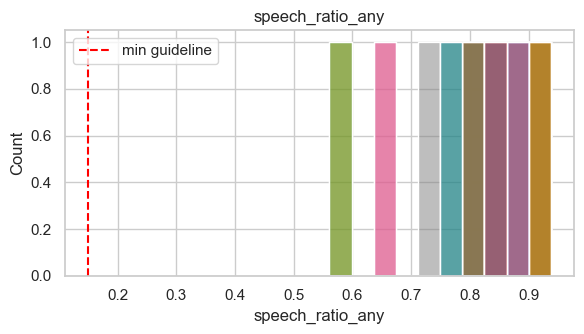

**คำอธิบาย (ภาษาไทย):** อ่านค่า speech_ratio_any: ยิ่งใกล้ 1 ยิ่งมีช่วงพูดเยอะ ถ้ากองค่าต่ำกว่าเส้น 0.15 แปลว่าไฟล์เงียบ/พูดน้อย อาจไม่เหมาะกับ ASR

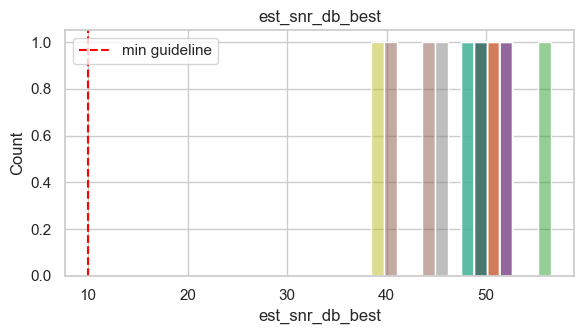

**คำอธิบาย (ภาษาไทย):** อ่านค่า SNR: ยิ่งสูงเสียงพูดชัดกว่า noise ถ้าส่วนใหญ่ต่ำกว่า 10 dB ให้พิจารณา denoise หรือคัดไฟล์

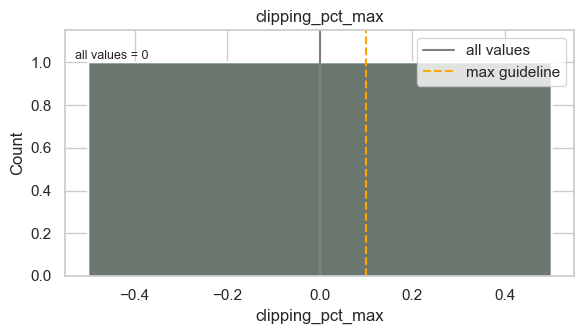

**คำอธิบาย (ภาษาไทย):** อ่านค่า clipping: ค่ายิ่งสูงยิ่งเสียงแตก ถ้าเกิน 0.10% บ่อย ๆ คือมี clipping ชัด

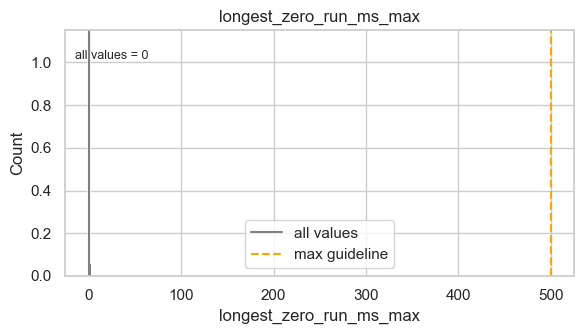

**คำอธิบาย (ภาษาไทย):** อ่านค่า dropout: ช่วงเงียบยาวผิดปกติ ถ้าเกิน 500 ms บ่อย ๆ อาจมีเสียงขาดหรือ dead air

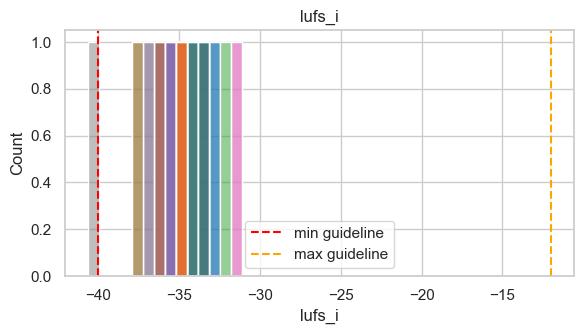

**คำอธิบาย (ภาษาไทย):** อ่านค่า LUFS: ช่วงเหมาะสมอยู่ระหว่าง -40 ถึง -12 ถ้าต่ำกว่า = เบาเกินไป สูงกว่า = ดังเกินไป

In [63]:
sns.set_theme(style="whitegrid")

def hist_with_guides(col, title, min_val=None, max_val=None):
    fig, ax = plt.subplots(figsize=(6, 3.5))
    if col not in df:
        return
    col_data = df[col].dropna()
    if col_data.empty:
        ax.text(0.5, 0.5, 'No numeric values', transform=ax.transAxes, ha='center', va='center')
        plt.show()
        return
    unique_count = col_data.nunique()
    kde_flag = (col_data.size >= 5) and (unique_count > 1)
    try:
        if "file_label" in df.columns:
            sns.histplot(
                data=df,
                x=col,
                hue="file_label",
                palette=color_map,
                multiple="layer",
                kde=kde_flag,
                common_norm=False,
                ax=ax,
            )
        else:
            sns.histplot(df[col].dropna(), kde=kde_flag, ax=ax)
    except Exception:
        # Fallback when KDE fails (e.g., tiny or constant data)
        if "file_label" in df.columns:
            sns.histplot(
                data=df,
                x=col,
                hue="file_label",
                palette=color_map,
                multiple="layer",
                kde=False,
                common_norm=False,
                ax=ax,
            )
        else:
            sns.histplot(df[col].dropna(), kde=False, ax=ax)
        ax.text(0.02, 0.98, 'KDE disabled (low variance)', transform=ax.transAxes, va='top', fontsize=9)
    if unique_count == 1:
        val = float(col_data.iloc[0])
        ax.axvline(val, color="gray", linestyle="-", label="all values")
        ax.text(0.02, 0.92, f'all values = {val:g}', transform=ax.transAxes, va='top', fontsize=9)
        try:
            sns.rugplot(col_data, ax=ax, color="gray", height=0.05)
        except Exception:
            pass
    ax.set_title(title)
    if min_val is not None:
        ax.axvline(min_val, color="red", linestyle="--", label="min guideline")
    if max_val is not None:
        ax.axvline(max_val, color="orange", linestyle="--", label="max guideline")
    if min_val is not None or max_val is not None or unique_count == 1:
        ax.legend()
    plt.tight_layout()
    plt.show()

HIST_EXPLAIN_TH = {
    "speech_ratio_any": "อ่านค่า speech_ratio_any: ยิ่งใกล้ 1 ยิ่งมีช่วงพูดเยอะ ถ้ากองค่าต่ำกว่าเส้น 0.15 แปลว่าไฟล์เงียบ/พูดน้อย อาจไม่เหมาะกับ ASR",
    "est_snr_db_best": "อ่านค่า SNR: ยิ่งสูงเสียงพูดชัดกว่า noise ถ้าส่วนใหญ่ต่ำกว่า 10 dB ให้พิจารณา denoise หรือคัดไฟล์",
    "clipping_pct_max": "อ่านค่า clipping: ค่ายิ่งสูงยิ่งเสียงแตก ถ้าเกิน 0.10% บ่อย ๆ คือมี clipping ชัด",
    "longest_zero_run_ms_max": "อ่านค่า dropout: ช่วงเงียบยาวผิดปกติ ถ้าเกิน 500 ms บ่อย ๆ อาจมีเสียงขาดหรือ dead air",
    "lufs_i": "อ่านค่า LUFS: ช่วงเหมาะสมอยู่ระหว่าง -40 ถึง -12 ถ้าต่ำกว่า = เบาเกินไป สูงกว่า = ดังเกินไป",
}
plot_specs = [
    ("speech_ratio_any", 0.15, None),
    ("est_snr_db_best", 10.0, None),
    ("clipping_pct_max", None, 0.10),
    ("longest_zero_run_ms_max", None, 500.0),
    ("lufs_i", -40.0, -12.0),
]

for key, vmin, vmax in plot_specs:
    hist_with_guides(key, key, vmin, vmax)
    if 'display' in globals():
        text = HIST_EXPLAIN_TH.get(key, '')
        if text:
            display(Markdown(f'**คำอธิบาย (ภาษาไทย):** {text}'))


## Scatter plots


### How to read these scatter plots
- Each dot is one file; axes are two metrics. Color matches the file label (F1/F2/...)
- Dots far from the main cluster are outliers to review.
- If dots form a slope, it suggests a relationship (e.g., louder files may show better SNR).
- Use guideline lines to see if points fall into acceptable regions.
- Jitter is added in some plots to separate overlapping points.


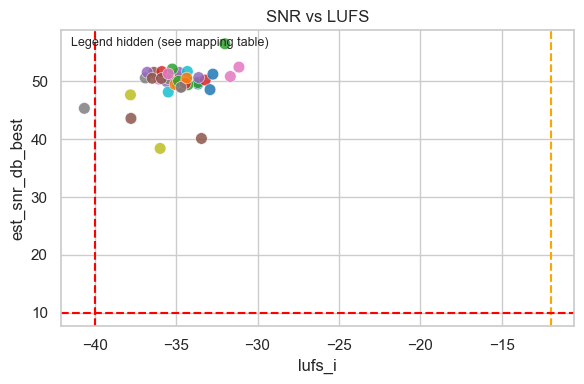

**คำอธิบาย (ภาษาไทย):** อ่านกราฟ SNR vs LUFS: จุดที่อยู่ในช่วง LUFS [-40, -12] และ SNR >= 10 dB คือกลุ่มที่เสียงค่อนข้างดี (ดังพอดีและชัด) จุดนอกกรอบคือไฟล์ที่ควรตรวจ

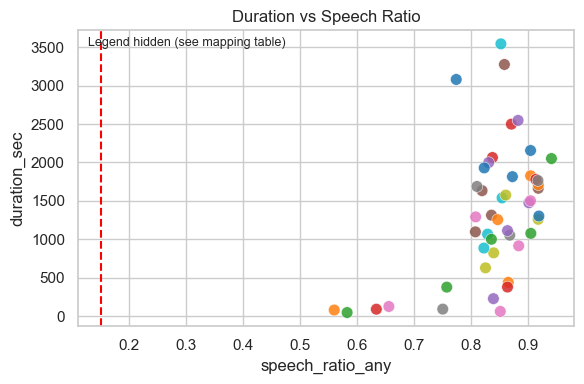

**คำอธิบาย (ภาษาไทย):** อ่านกราฟ Duration vs Speech Ratio: ไฟล์ยาวแต่ speech_ratio ต่ำแปลว่ามีช่วงเงียบเยอะ/hold/dead air สูง จุดที่ speech_ratio สูงและ duration พอเหมาะมักใช้ได้ดี

In [64]:
def scatter_with_guides(x, y, x_min=None, x_max=None, y_min=None, y_max=None, title=None, jitter=False):
    fig, ax = plt.subplots(figsize=(6, 4))
    plot_df = df.copy()
    if jitter:
        x_range = plot_df[x].max() - plot_df[x].min()
        y_range = plot_df[y].max() - plot_df[y].min()
        if np.isfinite(x_range) and x_range > 0:
            plot_df[x] = plot_df[x] + np.random.uniform(-0.01 * x_range, 0.01 * x_range, size=len(plot_df))
        if np.isfinite(y_range) and y_range > 0:
            plot_df[y] = plot_df[y] + np.random.uniform(-0.01 * y_range, 0.01 * y_range, size=len(plot_df))
    if "file_label" in plot_df.columns:
        n_labels = plot_df["file_label"].nunique()
        show_legend = n_labels <= 12
        sns.scatterplot(
            data=plot_df,
            x=x,
            y=y,
            hue="file_label",
            palette=color_map,
            s=70,
            alpha=0.85,
            edgecolor="white",
            linewidth=0.4,
            ax=ax,
            legend=show_legend,
        )
        if show_legend:
            ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, title="file_label")
        else:
            ax.text(0.02, 0.98, "Legend hidden (see mapping table)", transform=ax.transAxes, va="top", fontsize=9)
    else:
        sns.scatterplot(x=plot_df[x], y=plot_df[y], ax=ax, s=70, alpha=0.85, edgecolor="white", linewidth=0.4)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(title or f"{y} vs {x}")
    if x_min is not None:
        ax.axvline(x_min, color="red", linestyle="--")
    if x_max is not None:
        ax.axvline(x_max, color="orange", linestyle="--")
    if y_min is not None:
        ax.axhline(y_min, color="red", linestyle="--")
    if y_max is not None:
        ax.axhline(y_max, color="orange", linestyle="--")
    plt.tight_layout()
    plt.show()

SCATTER_EXPLAIN_TH = {
    "SNR vs LUFS": "อ่านกราฟ SNR vs LUFS: จุดที่อยู่ในช่วง LUFS [-40, -12] และ SNR >= 10 dB คือกลุ่มที่เสียงค่อนข้างดี (ดังพอดีและชัด) จุดนอกกรอบคือไฟล์ที่ควรตรวจ",
    "Duration vs Speech Ratio": "อ่านกราฟ Duration vs Speech Ratio: ไฟล์ยาวแต่ speech_ratio ต่ำแปลว่ามีช่วงเงียบเยอะ/hold/dead air สูง จุดที่ speech_ratio สูงและ duration พอเหมาะมักใช้ได้ดี",
}

if {"lufs_i", "est_snr_db_best"}.issubset(df.columns):
    scatter_with_guides(
        "lufs_i",
        "est_snr_db_best",
        x_min=-40.0,
        x_max=-12.0,
        y_min=10.0,
        title="SNR vs LUFS",
    )
    if 'display' in globals():
        display(Markdown(f"**คำอธิบาย (ภาษาไทย):** {SCATTER_EXPLAIN_TH.get('SNR vs LUFS', '')}"))

if {"speech_ratio_any", "duration_sec"}.issubset(df.columns):
    scatter_with_guides(
        "speech_ratio_any",
        "duration_sec",
        x_min=0.15,
        title="Duration vs Speech Ratio",
        jitter=True,
    )
    if 'display' in globals():
        display(Markdown(f"**คำอธิบาย (ภาษาไทย):** {SCATTER_EXPLAIN_TH.get('Duration vs Speech Ratio', '')}"))


## Interpretation notes
- Values outside guidelines are not automatically bad; treat them as candidates to review.
- Tune thresholds by inspecting distributions on 100-500 files (percentile-based cutoffs work well).
- If LUFS is NaN, scipy might be missing or the audio is too short.
